# California Housing — Regression ML Pipeline

**Dataset**: California Housing (sklearn built-in) — 20,640 samples, 8 numeric features.  
**Target**: `MedHouseVal` — median house value in blocks of $100k.

This notebook mirrors the classification pipeline but focuses on **regression-specific** topics:

| Section | Topic |
|---|---|
| 1 | Dataset loading & description |
| 2 | Exploratory Data Analysis |
| 3 | Preprocessing (split + scale) |
| 4 | First model: Linear Regression (naive baseline) |
| 5 | Evaluation metrics — **manual implementation then sklearn** |
| 6 | Residual analysis |
| 7 | Cross-validation (multi-metric) |
| 8 | Multi-model comparison |
| 9 | Feature importance |
| 10 | Learning curves |
| 11 | Hyperparameter tuning + final test evaluation |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import (
    train_test_split, cross_val_score, cross_validate,
    KFold, RandomizedSearchCV, learning_curve
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    median_absolute_error, mean_absolute_percentage_error
)
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR

import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
np.random.seed(42)
print('Imports OK')

Imports OK


---
## 1. Dataset — California Housing

Built into sklearn, no download needed. Predict median house value from block-level census features.

In [2]:
housing = fetch_california_housing(as_frame=True)
df = housing.frame   # DataFrame with 8 features + target

print(f'Shape: {df.shape}  ({df.shape[0]:,} samples, {df.shape[1]} columns)')
print(f'Features: {list(df.columns[:-1])}')
print(f'Target:   MedHouseVal  (median house value, unit = $100k)')
print()
print('--- Feature descriptions ---')
print('MedInc:    median income in block group (tens of thousands $)')
print('HouseAge:  median house age in block group (years)')
print('AveRooms:  average number of rooms per household')
print('AveBedrms: average number of bedrooms per household')
print('Population: block group population')
print('AveOccup:  average household size')
print('Latitude, Longitude: geographic coordinates')

Shape: (20640, 9)  (20,640 samples, 9 columns)
Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Target:   MedHouseVal  (median house value, unit = $100k)

--- Feature descriptions ---
MedInc:    median income in block group (tens of thousands $)
HouseAge:  median house age in block group (years)
AveRooms:  average number of rooms per household
AveBedrms: average number of bedrooms per household
Population: block group population
AveOccup:  average household size
Latitude, Longitude: geographic coordinates


In [3]:
print('First 5 rows:')
display(df.head())
print()
df.info()

First 5 rows:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [4]:
df.describe().round(2)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00
mean,3.87,28.64,5.43,1.10,1425.48,3.07,35.63,-119.57,2.07
std,1.90,12.59,2.47,0.47,1132.46,10.39,2.14,2.00,1.15
min,0.50,1.00,0.85,0.33,3.00,0.69,32.54,-124.35,0.15
25%,2.56,18.00,4.44,1.01,787.00,2.43,33.93,-121.80,1.20
50%,3.53,29.00,5.23,1.05,1166.00,2.82,34.26,-118.49,1.80
75%,4.74,37.00,6.05,1.10,1725.00,3.28,37.71,-118.01,2.65
max,15.00,52.00,141.91,34.07,35682.00,1243.33,41.95,-114.31,5.00


In [5]:
print('Missing values per column:')
print(df.isnull().sum())
print(f'\nTotal nulls: {df.isnull().sum().sum()}  (clean dataset, no imputation needed)')

Missing values per column:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

Total nulls: 0  (clean dataset, no imputation needed)


---
## 2. Exploratory Data Analysis (EDA)

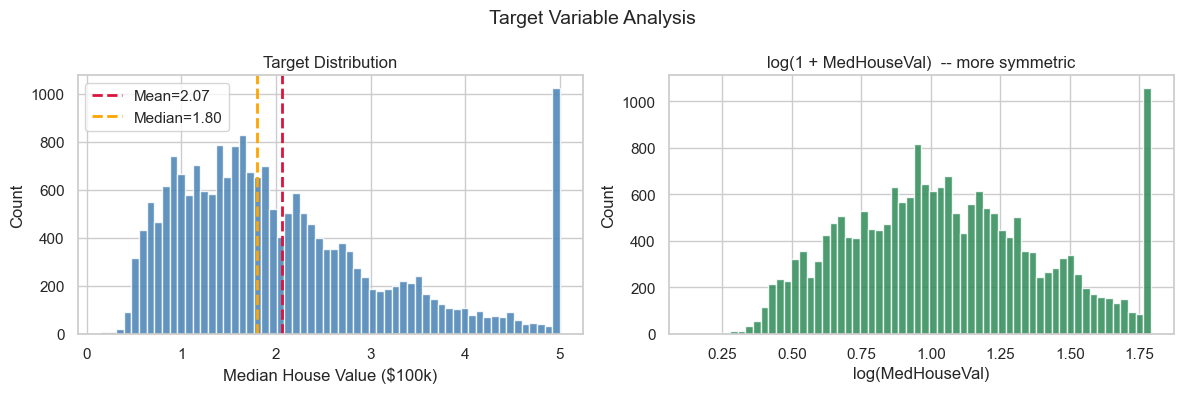

min=0.15  max=5.00  mean=2.07  std=1.15
Note: spike at 5.0 = values were capped at $500k during data collection


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['MedHouseVal'], bins=60, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(df['MedHouseVal'].mean(), color='crimson', lw=2, linestyle='--',
                label=f"Mean={df['MedHouseVal'].mean():.2f}")
axes[0].axvline(df['MedHouseVal'].median(), color='orange', lw=2, linestyle='--',
                label=f"Median={df['MedHouseVal'].median():.2f}")
axes[0].set(title='Target Distribution', xlabel='Median House Value ($100k)', ylabel='Count')
axes[0].legend()

# log transform makes skewed targets more symmetric — often improves linear models
axes[1].hist(np.log1p(df['MedHouseVal']), bins=60, color='seagreen', edgecolor='white', alpha=0.85)
axes[1].set(title='log(1 + MedHouseVal)  -- more symmetric',
            xlabel='log(MedHouseVal)', ylabel='Count')

plt.suptitle('Target Variable Analysis', fontsize=14)
plt.tight_layout()
plt.show()

print(f'min={df["MedHouseVal"].min():.2f}  max={df["MedHouseVal"].max():.2f}  '
      f'mean={df["MedHouseVal"].mean():.2f}  std={df["MedHouseVal"].std():.2f}')
print('Note: spike at 5.0 = values were capped at $500k during data collection')

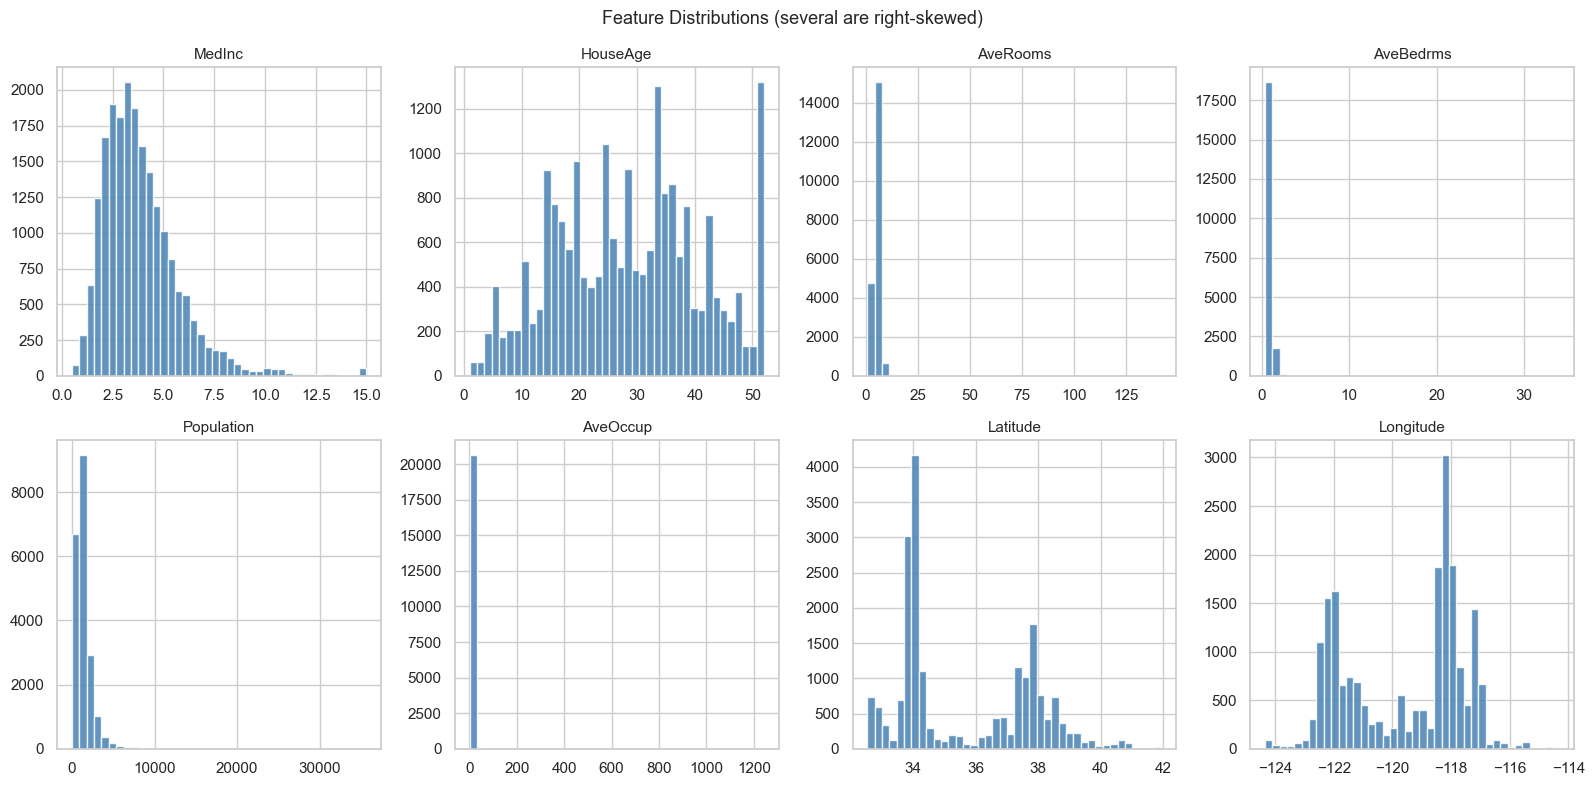

In [7]:
features = [c for c in df.columns if c != 'MedHouseVal']
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, feat in zip(axes.flatten(), features):
    ax.hist(df[feat], bins=40, color='steelblue', edgecolor='white', alpha=0.85)
    ax.set_title(feat, fontsize=11)
plt.suptitle('Feature Distributions (several are right-skewed)', fontsize=13)
plt.tight_layout()
plt.show()

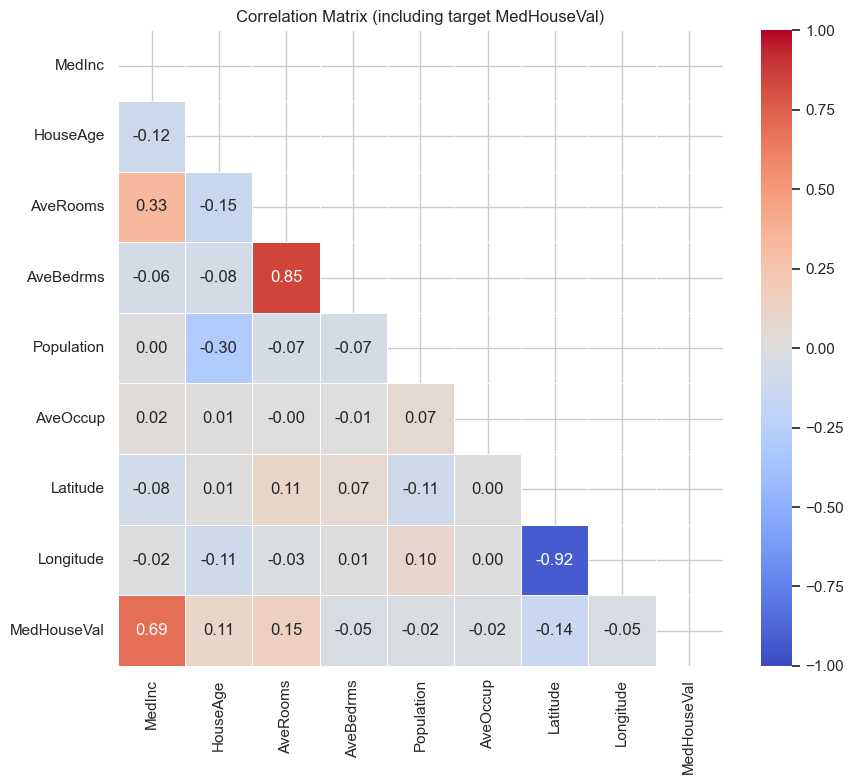

Correlations with target (sorted by magnitude):
  MedInc          |r|=0.688 (+)
  AveRooms        |r|=0.152 (+)
  Latitude        |r|=0.144 (-)
  HouseAge        |r|=0.106 (+)
  AveBedrms       |r|=0.047 (-)
  Longitude       |r|=0.046 (-)
  Population      |r|=0.025 (-)
  AveOccup        |r|=0.024 (-)


In [8]:
corr = df.corr()
fig, ax = plt.subplots(figsize=(9, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix (including target MedHouseVal)')
plt.tight_layout()
plt.show()

print('Correlations with target (sorted by magnitude):')
top = corr['MedHouseVal'].drop('MedHouseVal').abs().sort_values(ascending=False)
for feat, v in top.items():
    direction = '(+)' if corr['MedHouseVal'][feat] > 0 else '(-)'
    print(f'  {feat:<15} |r|={v:.3f} {direction}')

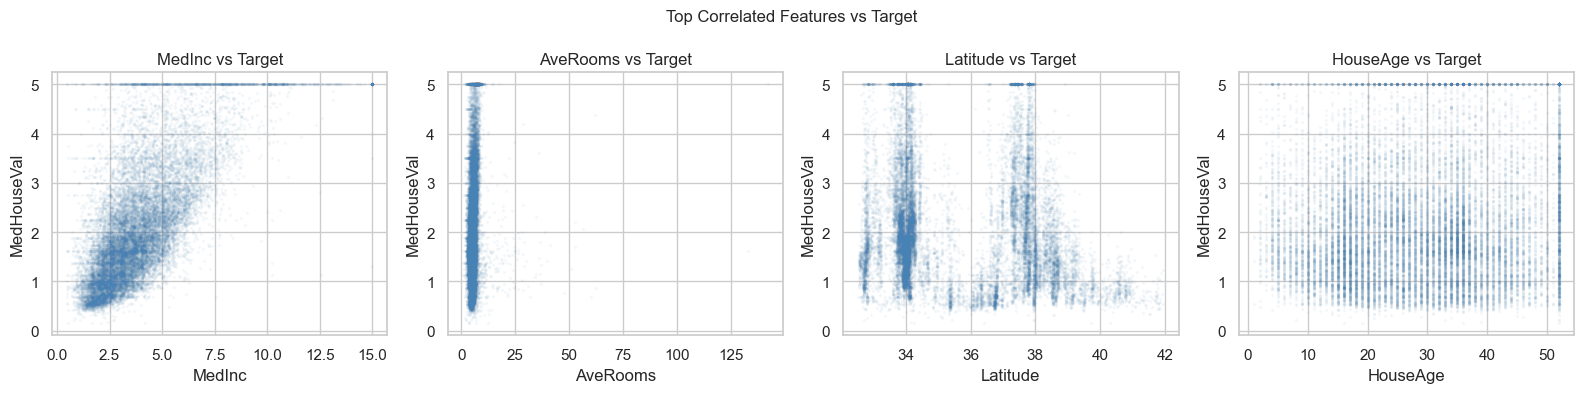

In [9]:
top_feats = corr['MedHouseVal'].drop('MedHouseVal').abs().sort_values(ascending=False).head(4).index.tolist()
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, feat in zip(axes, top_feats):
    ax.scatter(df[feat], df['MedHouseVal'], alpha=0.04, s=2, color='steelblue')
    ax.set(xlabel=feat, ylabel='MedHouseVal', title=f'{feat} vs Target')
plt.suptitle('Top Correlated Features vs Target', fontsize=12)
plt.tight_layout()
plt.show()

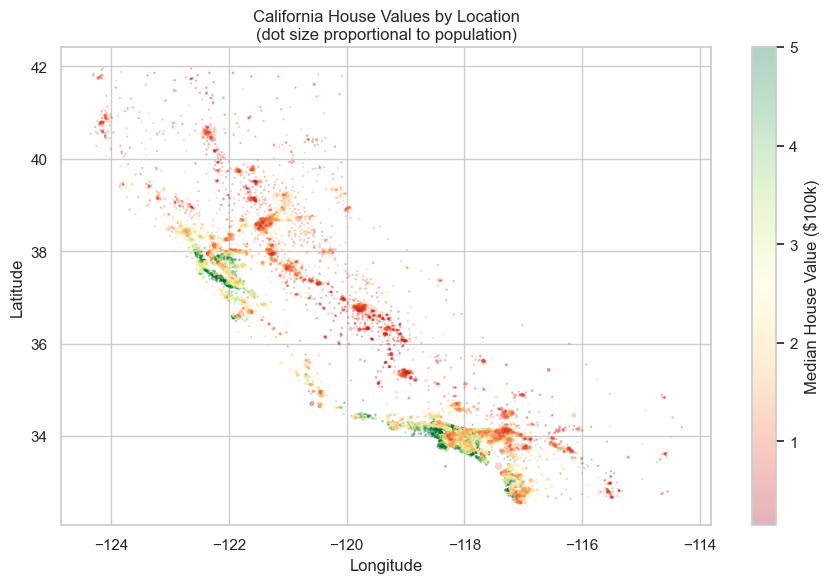

Clear pattern: coastal and Bay Area blocks have the highest values


In [10]:
fig, ax = plt.subplots(figsize=(9, 6))
sc = ax.scatter(
    df['Longitude'], df['Latitude'],
    c=df['MedHouseVal'], cmap='RdYlGn',
    s=df['Population'] / df['Population'].max() * 20,
    alpha=0.3,
)
plt.colorbar(sc, ax=ax, label='Median House Value ($100k)')
ax.set(xlabel='Longitude', ylabel='Latitude',
       title='California House Values by Location\n(dot size proportional to population)')
plt.tight_layout()
plt.show()
print('Clear pattern: coastal and Bay Area blocks have the highest values')

---
## 3. Preprocessing

Regression vs classification differences:
- **No label encoding** needed — target is already numeric
- Use `KFold` (not `StratifiedKFold`) for CV — continuous target can't be stratified
- Scaling still matters for distance-based (KNN, SVR) and regularized (Ridge, Lasso) models

In [11]:
X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']

# 70% train / 15% val / 15% test
X_train, X_tmp, y_train, y_tmp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val,   X_test, y_val,   y_test = train_test_split(X_tmp, y_tmp, test_size=0.5, random_state=42)

print(f'Train: {len(X_train):,}   Val: {len(X_val):,}   Test: {len(X_test):,}')
print(f'\nTrain target stats:')
print(f'  mean={y_train.mean():.3f}  std={y_train.std():.3f}  '
      f'min={y_train.min():.2f}  max={y_train.max():.2f}')

Train: 14,448   Val: 3,096   Test: 3,096

Train target stats:
  mean=2.069  std=1.157  min=0.15  max=5.00


In [12]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

print('After scaling, train column means (should be ~0):')
print(pd.Series(X_train_sc.mean(axis=0), index=X.columns).round(5).to_dict())
print('After scaling, train column stds (should be ~1):')
print(pd.Series(X_train_sc.std(axis=0), index=X.columns).round(4).to_dict())

After scaling, train column means (should be ~0):
{'MedInc': -0.0, 'HouseAge': -0.0, 'AveRooms': 0.0, 'AveBedrms': 0.0, 'Population': 0.0, 'AveOccup': 0.0, 'Latitude': -0.0, 'Longitude': 0.0}
After scaling, train column stds (should be ~1):
{'MedInc': 1.0, 'HouseAge': 1.0, 'AveRooms': 1.0, 'AveBedrms': 1.0, 'Population': 1.0, 'AveOccup': 1.0, 'Latitude': 1.0, 'Longitude': 1.0}


---
## 4. First Model — Linear Regression (Baseline)

Linear Regression fits **y = Xw + b** by minimizing MSE (solved in closed form).
Use it as the baseline to beat. If a complex model barely improves on it, linear might be enough.

In [13]:
lr = LinearRegression()
lr.fit(X_train_sc, y_train)

y_pred_val  = lr.predict(X_val_sc)
y_pred_test = lr.predict(X_test_sc)

print('Coefficients (sorted by absolute magnitude):')
coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': lr.coef_})
coef_df = coef_df.reindex(coef_df['Coefficient'].abs().sort_values(ascending=False).index)
display(coef_df.round(4).reset_index(drop=True))
print(f'\nIntercept: {lr.intercept_:.4f}')
print()
print('First 5 predictions vs true values:')
comp = pd.DataFrame({'True': y_val.values[:5], 'Predicted': y_pred_val[:5].round(3)})
comp['Error'] = (comp['True'] - comp['Predicted']).round(3)
display(comp)

Coefficients (sorted by absolute magnitude):


,Feature,Coefficient
0,Latitude,-0.8939
1,Longitude,-0.8686
2,MedInc,0.8492
3,AveBedrms,0.3484
4,AveRooms,-0.2996
5,HouseAge,0.1221
6,AveOccup,-0.0417
7,Population,-0.0009



Intercept: 2.0692

First 5 predictions vs true values:


,True,Predicted,Error
0,1.225,1.377,-0.152
1,3.204,3.271,-0.067
2,4.507,3.940,0.567
3,2.343,2.873,-0.530
4,1.019,1.988,-0.969


---
## 5. Evaluation Metrics

Regression errors measure how far predictions deviate from true values.

| Metric | Formula | Key property |
|---|---|---|
| **MAE** | mean(|y - y_hat|) | Same units as target, robust to outliers |
| **MSE** | mean((y - y_hat)^2) | Penalizes large errors quadratically |
| **RMSE** | sqrt(MSE) | Same units as target, most reported |
| **R squared** | 1 - SS_res / SS_tot | Fraction of variance explained (1.0 = perfect, 0 = predicting mean) |
| **MAPE** | mean(|y - y_hat| / |y|) * 100 | Percentage error; undefined if y = 0 |
| **MedAE** | median(|y - y_hat|) | Robust version of MAE |

We implement each **manually first**, then verify against sklearn.

In [14]:
# --- Manual implementations ---

def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

def mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

def rmse(y_true, y_pred):
    return np.sqrt(mse(y_true, y_pred))

def r2(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)            # residual sum of squares
    ss_tot = np.sum((y_true - y_true.mean()) ** 2)     # total sum of squares
    return 1 - ss_res / ss_tot

def mape(y_true, y_pred, eps=1e-8):
    # eps avoids division by zero; sklearn uses a similar guard
    return np.mean(np.abs((y_true - y_pred) / (np.abs(y_true) + eps))) * 100

def medae(y_true, y_pred):
    return np.median(np.abs(y_true - y_pred))

yt, yp = y_val.values, y_pred_val

print('=== Manual Implementation (Validation Set) ===')
print(f'MAE:   {mae(yt, yp):.4f}  -> avg error ~${mae(yt, yp)*100_000:.0f}')
print(f'MSE:   {mse(yt, yp):.4f}')
print(f'RMSE:  {rmse(yt, yp):.4f}  -> avg error ~${rmse(yt, yp)*100_000:.0f}')
print(f'R^2:   {r2(yt, yp):.4f}  -> explains {r2(yt, yp)*100:.1f}% of variance')
print(f'MAPE:  {mape(yt, yp):.2f}%')
print(f'MedAE: {medae(yt, yp):.4f}')

=== Manual Implementation (Validation Set) ===
MAE:   0.5335  -> avg error ~$53345
MSE:   0.5409
RMSE:  0.7354  -> avg error ~$73544
R^2:   0.5848  -> explains 58.5% of variance
MAPE:  32.15%
MedAE: 0.4142


In [15]:
# --- sklearn implementations (should match manual above) ---

print('=== sklearn Implementation (Validation Set) ===')
print(f'MAE:   {mean_absolute_error(yt, yp):.4f}')
print(f'MSE:   {mean_squared_error(yt, yp):.4f}')
print(f'RMSE:  {np.sqrt(mean_squared_error(yt, yp)):.4f}')
print(f'R^2:   {r2_score(yt, yp):.4f}')
print(f'MAPE:  {mean_absolute_percentage_error(yt, yp)*100:.2f}%')
print(f'MedAE: {median_absolute_error(yt, yp):.4f}')
print()

# Side-by-side comparison table
metrics_table = {
    'Metric': ['MAE', 'MSE', 'RMSE', 'R^2', 'MAPE (%)', 'MedAE'],
    'Manual': [
        mae(yt, yp), mse(yt, yp), rmse(yt, yp),
        r2(yt, yp), mape(yt, yp), medae(yt, yp)
    ],
    'sklearn': [
        mean_absolute_error(yt, yp),
        mean_squared_error(yt, yp),
        np.sqrt(mean_squared_error(yt, yp)),
        r2_score(yt, yp),
        mean_absolute_percentage_error(yt, yp) * 100,
        median_absolute_error(yt, yp),
    ],
    'Interpretation': [
        'Avg |error| in $100k units',
        'Penalizes large errors more',
        'Same units as target ($100k)',
        '0 = predict mean, 1 = perfect',
        '% deviation from true value',
        'Median error, robust to outliers',
    ],
}
display(pd.DataFrame(metrics_table).round(4))

=== sklearn Implementation (Validation Set) ===
MAE:   0.5335
MSE:   0.5409
RMSE:  0.7354
R^2:   0.5848
MAPE:  32.15%
MedAE: 0.4142



,Metric,Manual,sklearn,Interpretation
0,MAE,0.5335,0.5335,Avg |error| in $100k units
1,MSE,0.5409,0.5409,Penalizes large errors more
2,RMSE,0.7354,0.7354,Same units as target ($100k)
3,R^2,0.5848,0.5848,"0 = predict mean, 1 = perfect"
4,MAPE (%),32.1544,32.1544,% deviation from true value
5,MedAE,0.4142,0.4142,"Median error, robust to outliers"


---
## 6. Residual Analysis

Residuals = true - predicted. Three key plots diagnose model quality:
1. **Residuals vs Fitted**: random scatter around 0 = good. Patterns = model misspecification.
2. **Residual histogram**: should be approximately normal, centered at 0.
3. **Predicted vs Actual**: points should lie on the diagonal.

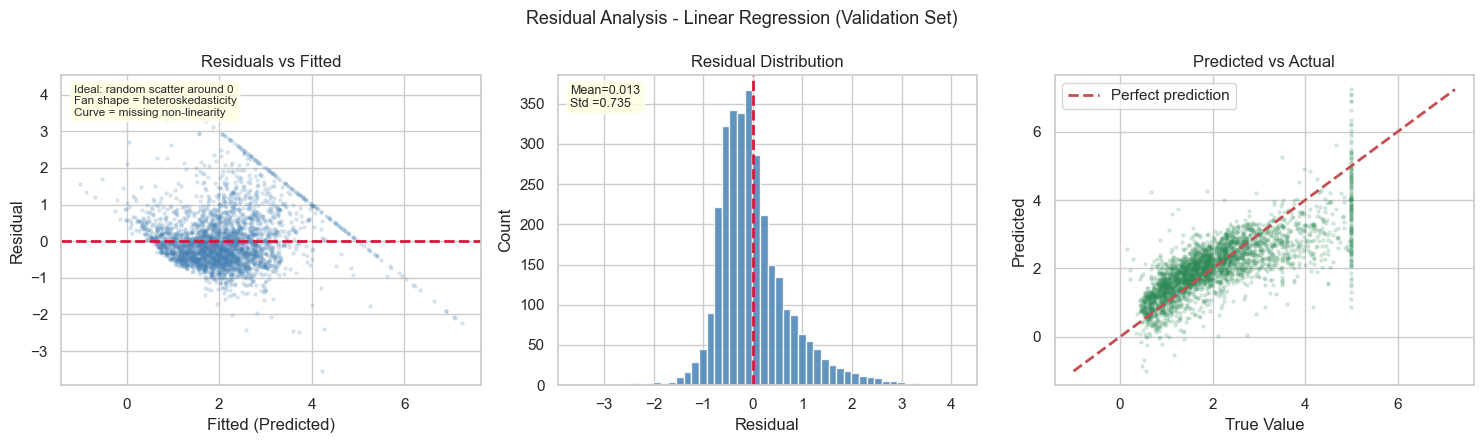

Observation: the fan pattern (wider residuals at higher values) suggests
heteroskedasticity. Non-linear models may capture this better.


In [16]:
residuals = yt - yp

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# 1) Residuals vs Fitted
axes[0].scatter(yp, residuals, alpha=0.15, s=5, color='steelblue')
axes[0].axhline(0, color='crimson', lw=2, linestyle='--')
axes[0].set(xlabel='Fitted (Predicted)', ylabel='Residual',
            title='Residuals vs Fitted')
axes[0].text(0.03, 0.97,
             'Ideal: random scatter around 0\nFan shape = heteroskedasticity\nCurve = missing non-linearity',
             transform=axes[0].transAxes, va='top', fontsize=8.5,
             bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

# 2) Residual histogram
axes[1].hist(residuals, bins=50, color='steelblue', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='crimson', lw=2, linestyle='--')
axes[1].set(xlabel='Residual', ylabel='Count', title='Residual Distribution')
axes[1].text(0.03, 0.97, f'Mean={residuals.mean():.3f}\nStd ={residuals.std():.3f}',
             transform=axes[1].transAxes, va='top', fontsize=9,
             bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

# 3) Predicted vs Actual
axes[2].scatter(yt, yp, alpha=0.15, s=5, color='seagreen')
lo, hi = min(float(yt.min()), float(yp.min())), max(float(yt.max()), float(yp.max()))
axes[2].plot([lo, hi], [lo, hi], 'r--', lw=2, label='Perfect prediction')
axes[2].set(xlabel='True Value', ylabel='Predicted', title='Predicted vs Actual')
axes[2].legend()

plt.suptitle('Residual Analysis - Linear Regression (Validation Set)', fontsize=13)
plt.tight_layout()
plt.show()

print('Observation: the fan pattern (wider residuals at higher values) suggests')
print('heteroskedasticity. Non-linear models may capture this better.')

---
## 7. Cross-Validation (Multi-Metric)

`cross_validate` (vs `cross_val_score`) lets you compute multiple metrics at once and optionally
return train scores — useful for detecting overfitting.

In [17]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)
pipe_lr = Pipeline([('scaler', StandardScaler()), ('reg', LinearRegression())])

cv_res = cross_validate(
    pipe_lr, X_train, y_train, cv=cv,
    scoring={
        'neg_mae':  'neg_mean_absolute_error',
        'neg_rmse': 'neg_root_mean_squared_error',
        'r2':       'r2',
    },
    return_train_score=True,  # compare train vs val to detect overfitting
)

print('Cross-Validation (5-fold) - Linear Regression:')
val_mae  = -cv_res['test_neg_mae']
val_rmse = -cv_res['test_neg_rmse']
val_r2   =  cv_res['test_r2']
print(f'  MAE:  {val_mae.mean():.4f} +- {val_mae.std():.4f}  per-fold={val_mae.round(4)}')
print(f'  RMSE: {val_rmse.mean():.4f} +- {val_rmse.std():.4f}  per-fold={val_rmse.round(4)}')
print(f'  R^2:  {val_r2.mean():.4f} +- {val_r2.std():.4f}  per-fold={val_r2.round(4)}')
print()
print('Train vs Val R^2 (gap reveals overfitting):')
train_r2 = cv_res['train_r2']
print(f'  Train: {train_r2.mean():.4f} +- {train_r2.std():.4f}')
print(f'  Val:   {val_r2.mean():.4f} +- {val_r2.std():.4f}')
gap = train_r2.mean() - val_r2.mean()
print(f'  Gap:   {gap:.4f}  ->  {"minimal overfitting" if gap < 0.05 else "possible overfitting"}')

Cross-Validation (5-fold) - Linear Regression:
  MAE:  0.5316 +- 0.0073  per-fold=[0.5348 0.5439 0.5237 0.5303 0.5251]
  RMSE: 0.7246 +- 0.0121  per-fold=[0.7315 0.7408 0.729  0.7149 0.707 ]
  R^2:  0.6074 +- 0.0202  per-fold=[0.6113 0.5819 0.5865 0.6326 0.625 ]

Train vs Val R^2 (gap reveals overfitting):
  Train: 0.6095 +- 0.0051
  Val:   0.6074 +- 0.0202
  Gap:   0.0020  ->  minimal overfitting


---
## 8. Multi-Model Comparison

California Housing has non-linear interactions (especially location). Expect tree-based models
to outperform linear ones significantly.

In [18]:
model_zoo = {
    'LinearRegression': LinearRegression(),
    'Ridge (a=1)':      Ridge(alpha=1.0),
    'Lasso (a=0.01)':   Lasso(alpha=0.01),
    'KNN (k=5)':        KNeighborsRegressor(n_neighbors=5),
    'DecisionTree':     DecisionTreeRegressor(random_state=42),
    'RandomForest':     RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'GradientBoosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'SVR (RBF)':        SVR(kernel='rbf'),
}
print(f'{len(model_zoo)} models to compare:')
for name in model_zoo:
    print(f'  {name}')

8 models to compare:
  LinearRegression
  Ridge (a=1)
  Lasso (a=0.01)
  KNN (k=5)
  DecisionTree
  RandomForest
  GradientBoosting
  SVR (RBF)


In [19]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)
results = []

for name, reg in model_zoo.items():
    pipe = Pipeline([('scaler', StandardScaler()), ('reg', reg)])
    cv_res = cross_validate(pipe, X_train, y_train, cv=cv,
                            scoring={'neg_rmse': 'neg_root_mean_squared_error', 'r2': 'r2'})
    pipe.fit(X_train, y_train)
    y_val_pred = pipe.predict(X_val)
    cv_rmse = -cv_res['test_neg_rmse'].mean()
    cv_r2   =  cv_res['test_r2'].mean()
    val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
    val_r2   = r2_score(y_val, y_val_pred)
    results.append({
        'Model':    name,
        'CV RMSE':  cv_rmse,
        'CV Std':   cv_res['test_neg_rmse'].std(),
        'CV R^2':   cv_r2,
        'Val RMSE': val_rmse,
        'Val R^2':  val_r2,
    })
    print(f'{name:<22}  CV RMSE={cv_rmse:.4f}  R^2={cv_r2:.4f}  ValR^2={val_r2:.4f}')

results_df = pd.DataFrame(results).sort_values('CV R^2', ascending=False).reset_index(drop=True)
print()
display(results_df.round(4))

LinearRegression        CV RMSE=0.7246  R^2=0.6074  ValR^2=0.5848
Ridge (a=1)             CV RMSE=0.7246  R^2=0.6074  ValR^2=0.5848
Lasso (a=0.01)          CV RMSE=0.7281  R^2=0.6036  ValR^2=0.5811
KNN (k=5)               CV RMSE=0.6613  R^2=0.6726  ValR^2=0.6550
DecisionTree            CV RMSE=0.7514  R^2=0.5773  ValR^2=0.5928
RandomForest            CV RMSE=0.5217  R^2=0.7964  ValR^2=0.7920
GradientBoosting        CV RMSE=0.5381  R^2=0.7835  ValR^2=0.7632
SVR (RBF)               CV RMSE=0.5997  R^2=0.7309  ValR^2=0.7143



,Model,CV RMSE,CV Std,CV R^2,Val RMSE,Val R^2
0,RandomForest,0.5217,0.0123,0.7964,0.5205,0.7920
1,GradientBoosting,0.5381,0.0123,0.7835,0.5554,0.7632
2,SVR (RBF),0.5997,0.0132,0.7309,0.6101,0.7143
3,KNN (k=5),0.6613,0.0172,0.6726,0.6704,0.6550
4,Ridge (a=1),0.7246,0.0121,0.6074,0.7354,0.5848
5,LinearRegression,0.7246,0.0121,0.6074,0.7354,0.5848
6,Lasso (a=0.01),0.7281,0.0138,0.6036,0.7388,0.5811
7,DecisionTree,0.7514,0.0305,0.5773,0.7284,0.5928


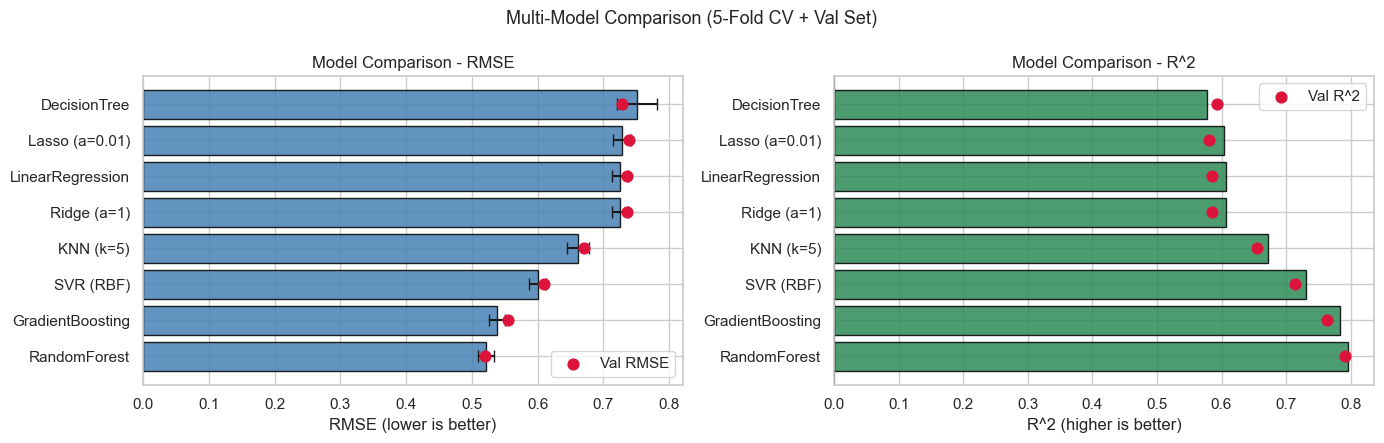

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# RMSE (lower is better)
axes[0].barh(results_df['Model'], results_df['CV RMSE'],
             xerr=results_df['CV Std'], color='steelblue', edgecolor='black',
             capsize=4, alpha=0.85)
axes[0].scatter(results_df['Val RMSE'], range(len(results_df)),
                color='crimson', zorder=5, s=60, label='Val RMSE')
axes[0].set(xlabel='RMSE (lower is better)', title='Model Comparison - RMSE')
axes[0].legend()

# R^2 (higher is better)
axes[1].barh(results_df['Model'], results_df['CV R^2'],
             color='seagreen', edgecolor='black', alpha=0.85)
axes[1].scatter(results_df['Val R^2'], range(len(results_df)),
                color='crimson', zorder=5, s=60, label='Val R^2')
axes[1].axvline(0, color='black', lw=0.8)
axes[1].set(xlabel='R^2 (higher is better)', title='Model Comparison - R^2')
axes[1].legend()

plt.suptitle('Multi-Model Comparison (5-Fold CV + Val Set)', fontsize=13)
plt.tight_layout()
plt.show()

---
## 9. Feature Importance

Two approaches:
- **Built-in** (Random Forest `feature_importances_`): based on how much each feature reduces impurity across all trees. Fast but can overstate importance of high-cardinality features.
- **Permutation importance**: shuffle each feature randomly, measure R^2 drop. Model-agnostic, more reliable, but slower.

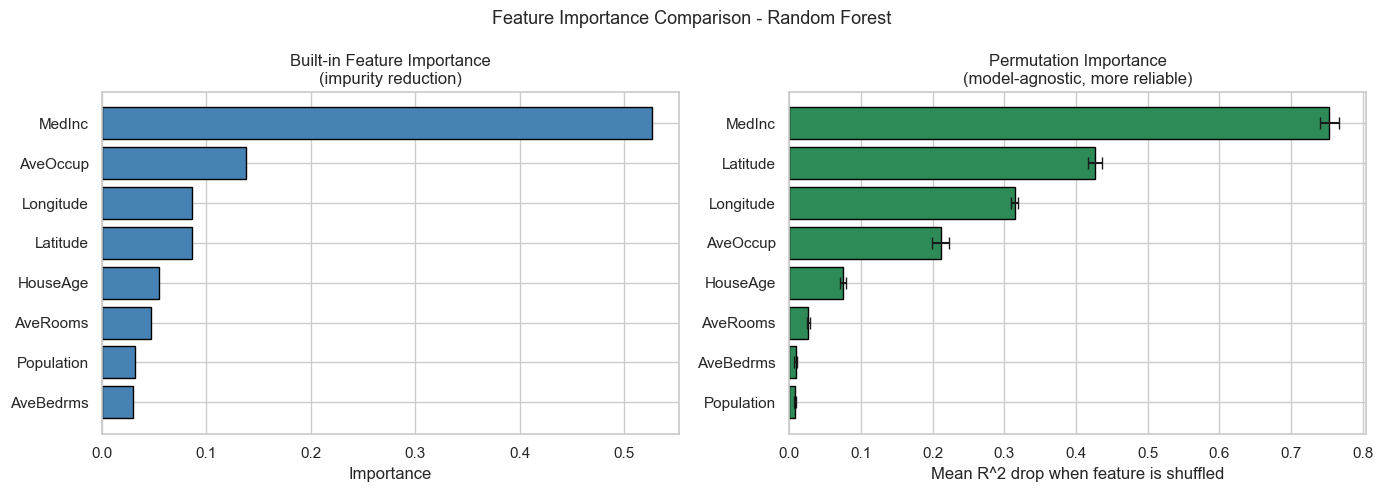

MedInc (median income) is by far the most important feature.


In [21]:
rf_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('reg', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)),
])
rf_pipe.fit(X_train, y_train)
rf_model = rf_pipe.named_steps['reg']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1) Built-in importance
imp_native = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=True)
axes[0].barh(imp_native.index, imp_native.values, color='steelblue', edgecolor='black')
axes[0].set(title='Built-in Feature Importance\n(impurity reduction)',
            xlabel='Importance')

# 2) Permutation importance on val set
perm = permutation_importance(
    rf_pipe, X_val, y_val, n_repeats=10, random_state=42, scoring='r2'
)
imp_mean = pd.Series(perm.importances_mean, index=X.columns)
imp_std  = pd.Series(perm.importances_std, index=X.columns)
order = imp_mean.sort_values().index
axes[1].barh(order, imp_mean[order], xerr=imp_std[order],
             color='seagreen', edgecolor='black', capsize=4)
axes[1].set(title='Permutation Importance\n(model-agnostic, more reliable)',
            xlabel='Mean R^2 drop when feature is shuffled')

plt.suptitle('Feature Importance Comparison - Random Forest', fontsize=13)
plt.tight_layout()
plt.show()

print('MedInc (median income) is by far the most important feature.')

---
## 10. Learning Curves

Learning curves show train vs validation score as training set size grows. They diagnose:
- **High bias (underfitting)**: both curves plateau at a low score — try a more complex model
- **High variance (overfitting)**: large train-val gap — try regularization or more data
- **Good fit**: val curve approaches train at a high score, gap is small

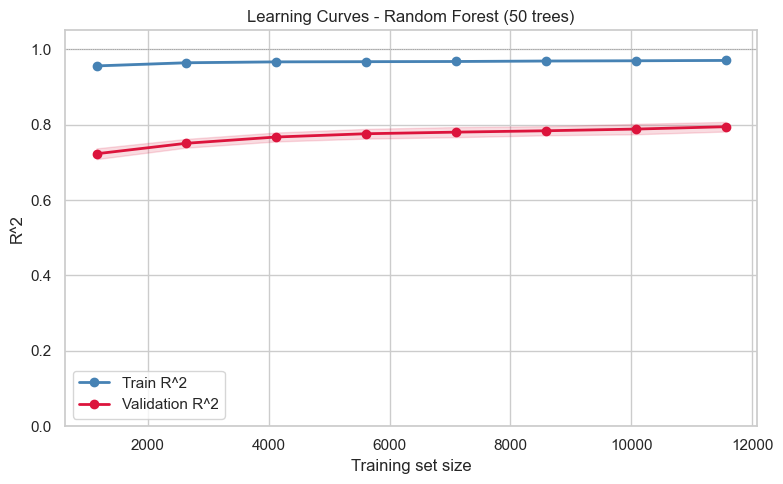

Final train R^2: 0.970
Final val   R^2: 0.794
Gap: 0.176
-> High variance (overfitting): consider more regularization or more data


In [22]:
pipe_lc = Pipeline([
    ('scaler', StandardScaler()),
    ('reg', RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)),
])

train_sizes, train_scores, val_scores = learning_curve(
    pipe_lc, X_train, y_train,
    train_sizes=np.linspace(0.1, 1.0, 8),
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    scoring='r2',
    n_jobs=-1,
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(train_sizes, train_mean, 'o-', color='steelblue', lw=2, label='Train R^2')
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std,
                alpha=0.15, color='steelblue')
ax.plot(train_sizes, val_mean, 'o-', color='crimson', lw=2, label='Validation R^2')
ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std,
                alpha=0.15, color='crimson')
ax.set(xlabel='Training set size', ylabel='R^2',
       title='Learning Curves - Random Forest (50 trees)', ylim=(0, 1.05))
ax.axhline(1.0, color='gray', lw=0.5, linestyle=':')
ax.legend()
plt.tight_layout()
plt.show()

gap = train_mean[-1] - val_mean[-1]
print(f'Final train R^2: {train_mean[-1]:.3f}')
print(f'Final val   R^2: {val_mean[-1]:.3f}')
print(f'Gap: {gap:.3f}')
if gap > 0.15:
    print('-> High variance (overfitting): consider more regularization or more data')
elif val_mean[-1] < 0.5:
    print('-> High bias (underfitting): try a more complex model')
else:
    print('-> Good fit')

---
## 11. Hyperparameter Tuning + Final Test Evaluation

`RandomizedSearchCV` samples *n_iter* random configs from a parameter distribution — much faster
than GridSearch for large spaces while usually finding similarly good parameters.

Evaluate on the test set **exactly once**, at the very end.

In [23]:
from scipy.stats import randint

param_dist = {
    'reg__n_estimators':      randint(100, 500),
    'reg__max_depth':         [None, 10, 15, 20, 30],
    'reg__min_samples_split': randint(2, 20),
    'reg__max_features':      ['sqrt', 'log2', 0.5],
    'reg__min_samples_leaf':  randint(1, 10),
}

pipe_rf = Pipeline([
    ('scaler', StandardScaler()),
    ('reg',    RandomForestRegressor(random_state=42, n_jobs=-1)),
])

rs = RandomizedSearchCV(
    pipe_rf, param_dist,
    n_iter=25,             # sample 25 random configs (vs all combos in GridSearch)
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    scoring='neg_root_mean_squared_error',
    random_state=42,
    n_jobs=-1,
    verbose=1,
    refit=True,
)
rs.fit(X_train, y_train)

print(f'\nBest params:   {rs.best_params_}')
print(f'Best CV RMSE:  {-rs.best_score_:.4f}')

Fitting 5 folds for each of 25 candidates, totalling 125 fits

Best params:   {'reg__max_depth': None, 'reg__max_features': 'log2', 'reg__min_samples_leaf': 2, 'reg__min_samples_split': 10, 'reg__n_estimators': 445}
Best CV RMSE:  0.5057


=== FINAL TEST SET EVALUATION - Tuned Random Forest ===
RMSE: 0.4819  (avg prediction error ~$48,193)
MAE:  0.3214  (avg abs error        ~$32,138)
R^2:  0.8244  (explains 82.4% of variance in house prices)
MAPE: 18.70%


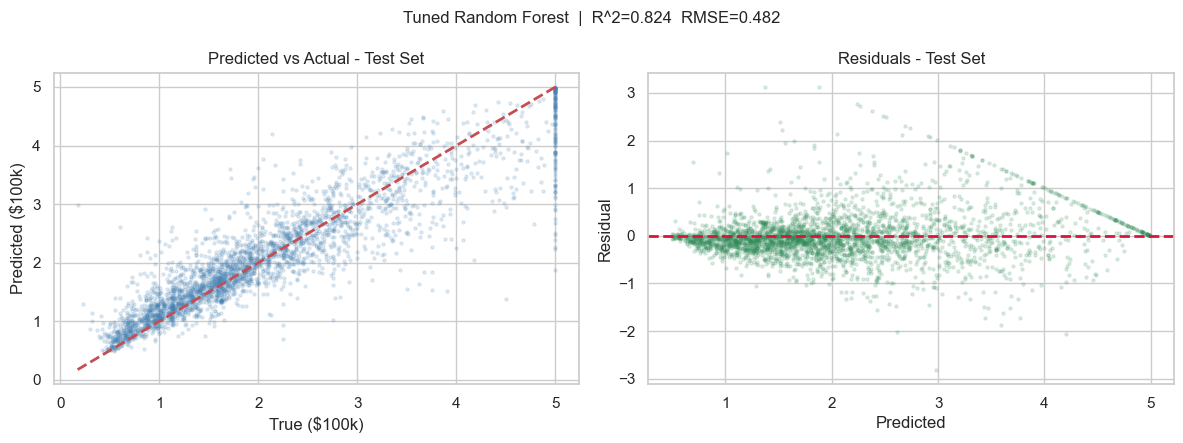

In [24]:
# FINAL: evaluate on test set exactly once
best = rs.best_estimator_
y_final = best.predict(X_test)

test_rmse = np.sqrt(mean_squared_error(y_test, y_final))
test_mae  = mean_absolute_error(y_test, y_final)
test_r2   = r2_score(y_test, y_final)
test_mape = mean_absolute_percentage_error(y_test, y_final) * 100

print('=== FINAL TEST SET EVALUATION - Tuned Random Forest ===')
print(f'RMSE: {test_rmse:.4f}  (avg prediction error ~${test_rmse*100_000:,.0f})')
print(f'MAE:  {test_mae:.4f}  (avg abs error        ~${test_mae*100_000:,.0f})')
print(f'R^2:  {test_r2:.4f}  (explains {test_r2*100:.1f}% of variance in house prices)')
print(f'MAPE: {test_mape:.2f}%')

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Predicted vs Actual
axes[0].scatter(y_test, y_final, alpha=0.15, s=5, color='steelblue')
lo, hi = float(y_test.min()), float(y_test.max())
axes[0].plot([lo, hi], [lo, hi], 'r--', lw=2)
axes[0].set(xlabel='True ($100k)', ylabel='Predicted ($100k)',
            title='Predicted vs Actual - Test Set')

# Residuals
res = y_test.values - y_final
axes[1].scatter(y_final, res, alpha=0.15, s=5, color='seagreen')
axes[1].axhline(0, color='crimson', lw=2, linestyle='--')
axes[1].set(xlabel='Predicted', ylabel='Residual', title='Residuals - Test Set')

plt.suptitle(f'Tuned Random Forest  |  R^2={test_r2:.3f}  RMSE={test_rmse:.3f}', fontsize=12)
plt.tight_layout()
plt.show()